# Welcome to lkdata!

lkdata is designed to handle time-series data transformations using the built-in power of pandas. lkdata serves at the backend for lightkurve v3. lightkurve users will typically not interact with lkdata directly. However, they are used for the affiliated packages lktimeseries and lkcubes to process Lightcurve (LC), Target Pixel File (TPF), and Full Frame Image (FFI) data for the TESS and Kepler/K2 missions. 

In this notbook, we will cover the basic properties of lkdata, as well as examples of how to use the built-in functionality. 

lkdata has three main classes to deal with data of different shapes and properties.
- Timeseries (such as LC) data is handled by DataSeries, BoolSeries, or BitwiseSeries depending on the data type (more on that in section 1 below)
- 3-dimensional data (such as TPF or FFI time series) are handled by DataCube
- Collections of timeseries-like arrays with shared times can be handled by SeriesCollection, BoolCollection, or BitwiseCollection. 

All of these data products require at a minimum some sort of temporal data (time, cadence number, etc) and data associated with those times. Errors associated with the data are also supported. When performing math operations on the data, such as adding, subtracting, or multiplying, these associated errors are handled appropriately (e.g., errors are automatically added in quadrature when appropriate). 

A mixture of any of these types of data can be bundled in a single DataSet, provided they all have the same times associated with them. The advantage of the DataSet is that operations applied to the DataSet, such as binning or slicing, are applied to all associated Series, Frame, and Cube objects as appropriate. For example, you could bundle a group of DataSeries that each represent a single source of flux (simple aperture flux, corrected flux, background flux, etc) and simulataneously cutout a time range of interest. We will see more applications for DataCubes in the examples throughout this notebook. 

In [164]:
# Import all of the packages we will use throughout this notebook
import sys
import os
parent_dir_name = os.path.dirname(os.path.dirname(os.path.dirname(os.path.realpath('lkdata'))))
sys.path.append(parent_dir_name + "/src")
import lkdata
import lksearch
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
print(lkdata.__path__)

['/Users/nthom/TESS_GI/gitNschanch/tessgi/lkdata/src/lkdata']


# 1 - Handling 1-Dimensional timeseries data

Data arrays that are associated with time values can be represented by one of three different classes: DataSeries, BoolSeries, or BitwiseSeries. DataSeries represent any numerical data that varies with time, such as flux, energy, or other lightcurve-like data. BoolSeries handle any Boolean data that varies by time, such as a Boolean mask for time steps that are 'good' or 'bad'. Finally, BitwiseSeries handle data that represents bitwise information. This was motivated by the TESS, Kepler, and K2 quality masks, which use bitwise AND operations to represent different combinations of data quality flags (Look [here](https://outerspace.stsci.edu/display/TESS/2.0+-+Data+Product+Overview#id-2.0-DataProductOverview-Table:CadenceQualityFlags) for more details). 

The DataSeries structure allows us to manipulate the data in a number of ways, including binning by time, slicing, folding, or doing mathematical operations. We will look at these in more detail in the following cells. 

Before we begin, let's create a random dataset to learn about the structure. We will apply this to real data in section */SOME SECTION/* below. 


### 1.1 DataSeries

The DataSeries object can be used to represent any series of numerical data that varies by time. Time in this case can be in any unit, but must be sorted from the first time step to the last time step. In this case below, we create a random time array, which could for example represent days since the start of the observation. 

In [3]:
# Generate some random times. 
times = np.linspace(0, 24, 120)

# Generate some random data
data = np.random.randn(len(times))

# Generate some errors
data_err = np.abs(data) * .1

All lkdata products require at a minimum some sort of data and an associated time. Multiple time indices are allowed (e.g. BJD, UTC, delta time, etc), but only a single data product is allowed. Associated uncertainties are optional. You can bundle multiple objects together using a DataSet. For more information on budling, see section 5 below. 

In [19]:
# TODO: can you give 'data' a keyword so there is a column label? Dictionary just doesn't work at all, but docs say it should
# TODO: Index=times looks like it should work in the docs, but doesn't
#       Docstring in general just inaccurate. time_indices not listed and index is confusing
# TODO: can't have the metadata be called 'name' as that is a reserved pandas thing


series = lkdata.DataSeries(data=data, #dict(zip(times, data)),
                       uncertainty=data_err,
                       time_indices={'time':times, 'offset_time':times+200},
                       extra_metadata = 'This is my first DataSeries', 
                    #index=times,
                          )
series

time_index  time       offset_time
0           0.000000   200.000000    -0.295683
1           0.201681   200.201681     0.323709
2           0.403361   200.403361     0.708202
3           0.605042   200.605042    -0.258286
4           0.806723   200.806723    -0.969952
                                        ...   
115         23.193277  223.193277    -0.010976
116         23.394958  223.394958     0.695469
117         23.596639  223.596639     1.965659
118         23.798319  223.798319    -1.164546
119         24.000000  224.000000    -0.568035
Length: 120, dtype: float64


📉 DataSeries (120,)

Great, we've initialized our first DataSeries! The representation of the object is very similar to a pandas DataFrame. The above cell shows that this is a DataSeries object with a length of 120. All time columns are included as a [MultiIndex](https://pandas.pydata.org/docs/user_guide/advanced.html). The uncertainties are not shown in the default [repr](https://docs.python.org/3/library/functions.html#repr), but you can see they are there using describe_series(), as shown below.

In [20]:
series.describe_series()

📉 DataSeries (120,) (120,) (ntime)

Uncertainty:
	uncertainty	:	Uncertainty(np.ndarray(120,))

Time indices available: ['time_index', 'time', 'offset_time']
	time_index     :	[  0   1 ... 118 119]
	time           :	[ 0.          0.20168067 ... 23.79831933 24.        ]
	offset_time    :	[200.         200.20168067 ... 223.79831933 224.        ]

User defined attributes accessible via `object.key`
(displaying only unique values)
	extra_metadata :	This is my first DataSeries


Note that there is now a keyword called 'time_index' that has been added to the multiindex. This is a unique array of index values that is automatically added when initializing a new DataSeries. You can access the different time arrays by using their keynames. 

In [23]:

print(series.time_index)
print(series.time)


[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]
[ 0.          0.20168067  0.40336134  0.60504202  0.80672269  1.00840336
  1.21008403  1.41176471  1.61344538  1.81512605  2.01680672  2.21848739
  2.42016807  2.62184874  2.82352941  3.02521008  3.22689076  3.42857143
  3.6302521   3.83193277  4.03361345  4.23529412  4.43697479  4.63865546
  4.84033613  5.04201681  5.24369748  5.44537815  5.64705882  5.8487395
  6.05042017  6.25210084  6.45378151  6.65546218  6.85714286  7.05882353
  7.2605042   7.46218487  7.66386555  7.86554622  8.06722689  8.26890756
  

### 1.2 BoolSeries

Creating a BoolSeries is very similar to creating a DataSeries. The main difference is that the data is now a boolean array. We will create one my making a boolean array based on the random data generated in Section 1.1.

In [25]:
# Create a boolean array based on the data values
mask = data > 0
print(mask)

[False  True  True False False False  True False  True  True False False
  True  True  True  True False False  True  True False False  True  True
 False False  True  True  True  True  True  True  True False False False
  True False False False False False  True  True False  True False  True
 False  True  True  True False False  True False  True False False False
  True False  True False  True  True False False  True  True False False
 False  True  True False False  True  True  True  True  True False  True
 False  True  True False False False  True False  True False  True  True
 False False  True False False False  True  True  True  True False False
 False  True False  True  True  True False False  True  True False False]


In [26]:
# TODO: Boolseries allow errors. Should they? In this case, it isn't an 'uncertainty' as such, just an array with that name so OK

boolseries = lkdata.BoolSeries(data=mask,
                        uncertainty = data_err,
                       time_indices={'time':times},
                        meta={'name':'myboolseries',}
                          )
boolseries.describe_series()

⚫️⚪️ BoolSeries (120,) (120,) (ntime)


Time indices available: ['time_index', 'time']
	time_index  :	[  0   1 ... 118 119]
	time        :	[ 0.          0.20168067 ... 23.79831933 24.        ]

User defined attributes accessible via `object.key`
(displaying only unique values)
	uncertainty :	[0.02956826 0.03237086 ... 0.11645461 0.05680353]
	meta        :	{'name': 'myboolseries'}


In this case, we assigned an uncertainty value as we did for the DataSeries. However, the data description shows that the uncertainty values are considered defined attributes, not true Uncertainty values. This is because uncertainties do not apply to Boolean values in the same way. Modifying the BoolSeries with not apply to these values, and they are treated strictly as additional metadata. 

In [31]:
series

time_index  time       offset_time
0           0.000000   200.000000     0.849511
1           0.201681   200.201681     0.481793
2           0.403361   200.403361    -0.284107
3           0.605042   200.605042     0.041269
4           0.806723   200.806723     0.666978
                                        ...   
235         29.865546  229.865546     1.046377
236         29.899160  229.899160    -0.942985
237         29.932773  229.932773    -0.010296
238         29.966387  229.966387     0.179611
239         30.000000  230.000000     1.260930
Length: 240, dtype: float64


📉 DataSeries (240,)

### 1.3 Manipulating DataSeries data

Once you have a Series object, you can manipulate it in various ways. Common actions you might make include slicing or binning the data. 

In the cell below, we demonstrate time binning. In lkdata, this is known as downsampling. By default, this combined 5 time steps. However, you can choose other time steps by specifying nframes=X. Currently, lkdata only allows for summing the data within time bins (with errors added in quadrature). 

TODO: Allow for other combination methods (mean and median)
TODO: Does it allow for a sliding window?

In [20]:
series.time[1] - series.time[0]

0.20168067226890757

In [21]:
series.time[-1] - series.time[-2]

0.20168067226890685

In [57]:
# Generate some random times. 
times = np.append(np.linspace(0, 24, 120), np.linspace(26,50, 120))

# Generate some random data
data = np.random.randn(len(times))

# Generate some errors
data_err = np.abs(data) * .1

series = lkdata.DataSeries(data=data, #dict(zip(times, data)),
                       uncertainty=data_err,
                       time_indices={'time':times, 'offset_time':times+200},
                       extra_metadata = 'This is my first DataSeries', 
                    #index=times,
                          )
series

time_index  time       offset_time
0           0.000000   200.000000     0.034333
1           0.201681   200.201681    -0.068169
2           0.403361   200.403361    -0.241818
3           0.605042   200.605042     1.623237
4           0.806723   200.806723    -0.016925
                                        ...   
235         49.193277  249.193277    -0.797419
236         49.394958  249.394958    -1.210956
237         49.596639  249.596639    -0.812235
238         49.798319  249.798319     0.658518
239         50.000000  250.000000     0.119482
Length: 240, dtype: float64


📉 DataSeries (240,)

In [58]:
# TODO - how does downsampling work for data series? I have mostly been working with DataCubes
# TODO - Dig in to how level works and the time steps (can only specify n_bins)
downsampled_series = series.downsample(level='time') # default 5 time steps
print(f"The series has shape {series.shape}")
print(f"The downsampled series has shape {downsampled_series.shape}")
downsampled_series

The series has shape (240,)
The downsampled series has shape (47,)
mid_index  indices                time       offset_time
2.0        [0 1 2 3 4]            0.403361   200.403361     1.330659
7.0        [5 6 7 8 9]            1.411765   201.411765    -1.044316
12.0       [10 11 12 13 14]       2.420168   202.420168    -0.239570
17.0       [15 16 17 18 19]       3.428571   203.428571     0.162307
22.0       [20 21 22 23 24]       4.436975   204.436975     2.345505
                                                              ...   
214.0      [212 213 214 215 216]  44.957983  244.957983    -6.604512
219.0      [217 218 219 220 221]  45.966387  245.966387    -0.865774
224.0      [222 223 224 225 226]  46.974790  246.974790     0.286903
229.0      [227 228 229 230 231]  47.983193  247.983193    -0.350507
234.0      [232 233 234 235 236]  48.991597  248.991597     0.142310
Length: 47, dtype: float64


📉 DataSeries (47,)

In [59]:
downsampled_series = series.downsample(level='time_index') # default 5 time steps
print(f"The series has shape {series.shape}")
print(f"The downsampled series has shape {downsampled_series.shape}")
downsampled_series

The series has shape (240,)
The downsampled series has shape (48,)
mid_index  indices                time       offset_time
2.0        [0 1 2 3 4]            0.403361   200.403361     1.330659
7.0        [5 6 7 8 9]            1.411765   201.411765    -1.044316
12.0       [10 11 12 13 14]       2.420168   202.420168    -0.239570
17.0       [15 16 17 18 19]       3.428571   203.428571     0.162307
22.0       [20 21 22 23 24]       4.436975   204.436975     2.345505
                                                              ...   
217.0      [215 216 217 218 219]  45.563025  245.563025    -0.830997
222.0      [220 221 222 223 224]  46.571429  246.571429     0.676686
227.0      [225 226 227 228 229]  47.579832  247.579832    -3.035141
232.0      [230 231 232 233 234]  48.588235  248.588235     3.279216
237.0      [235 236 237 238 239]  49.596639  249.596639    -2.042611
Length: 48, dtype: float64


📉 DataSeries (48,)

You are also able to easily slice the data. You can slice in the same manner you slice numpy arrays. In the example below we slice every other sample from the first 100 time steps in the DataSeries.

In [60]:
sliced_series = series[:100:2]
print(f"The series has shape {series.shape}")
print(f"The series after slicing has shape {sliced_series.shape}")
sliced_series

The series has shape (240,)
The series after slicing has shape (50,)
time_index  time       offset_time
0           0.000000   200.000000     0.034333
2           0.403361   200.403361    -0.241818
4           0.806723   200.806723    -0.016925
6           1.210084   201.210084    -0.574181
8           1.613445   201.613445    -1.624987
                                        ...   
90          18.151261  218.151261     1.249080
92          18.554622  218.554622     0.110376
94          18.957983  218.957983     0.458722
96          19.361345  219.361345     0.837320
98          19.764706  219.764706     0.744335
Length: 50, dtype: float64


📉 DataSeries (50,)

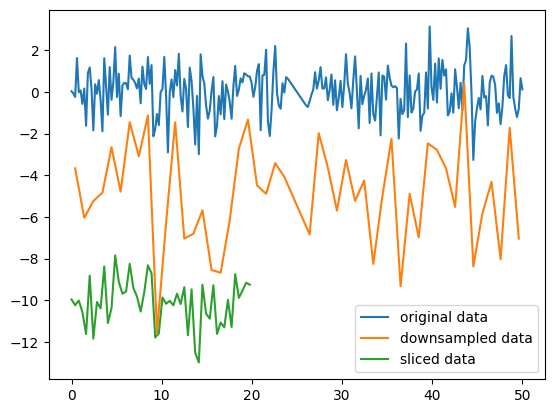

In [67]:
# Let's take a look at what these DataSeries look like
fig, ax = plt.subplots(1)
ax.plot(series.time, series.data, label='original data')
ax.plot(downsampled_series.time, downsampled_series.data - 5,label='downsampled data')
ax.plot(sliced_series.time, sliced_series.data - 10, label='sliced data')
ax.legend()
plt.show()

## 2 - Handling 2-Dimensional timeseries data

Now let's take a look at timseries of 2-D images. lkdata handles this type of data with the DataCube class. For TESS, Kepler, and K2 data, this would be the data structure used to describe image timeseries, such as TPFs and FFI data. The DataCube structure allows us to manipulate this data in a number of ways, including binning (either spatially or by time), slicing, folding, or doing mathematical operations. We will look at these in more detail in the following cells. 

Before we begin, let's create a random dataset to learn about the structure. We will apply this to real data in section */SOME SECTION/* below. 

One important thing to keep in mind with all lkdata structures is that they are designed to handle various types of time series data. This means that all products must be tied to at least one time array. We will see how this is important throughout this notebook.

### 2.1 creating a DataCube

In [68]:
# Generate some random times. 
times = np.linspace(0, 24, 120)


In [69]:
# Generate some random data
data = np.random.randn(len(times), 5,7)

# Generate some errors
data_err = np.abs(data) * .1



In [70]:
# print out the first 'image'
data[0,:,:], data_err[0,:,:]

(array([[ 0.44595873, -1.04654087, -0.98170559,  1.00924852,  0.11771452,
         -0.35506824,  0.40638933],
        [ 0.07127415,  1.19623119, -0.41136559,  0.92686754, -0.13971425,
          0.83871995, -0.35885363],
        [-1.54142823,  0.12984898,  1.2061007 ,  1.86935123,  1.67115969,
         -0.58837077, -1.01357005],
        [ 0.79018898, -0.41750869, -0.59238827, -0.73088011,  0.26472929,
         -0.76162962,  2.08547164],
        [-0.41025256, -0.90764987,  0.14532701, -1.0255024 ,  0.85119099,
         -0.42640191, -2.59238584]]),
 array([[0.04459587, 0.10465409, 0.09817056, 0.10092485, 0.01177145,
         0.03550682, 0.04063893],
        [0.00712741, 0.11962312, 0.04113656, 0.09268675, 0.01397142,
         0.08387199, 0.03588536],
        [0.15414282, 0.0129849 , 0.12061007, 0.18693512, 0.16711597,
         0.05883708, 0.101357  ],
        [0.0790189 , 0.04175087, 0.05923883, 0.07308801, 0.02647293,
         0.07616296, 0.20854716],
        [0.04102526, 0.09076499, 0.0

In [71]:
print(times.shape, data.shape, data_err.shape)

(120,) (120, 5, 7) (120, 5, 7)


We have now generated the data needed to make a DataCube. In this example, we are making a timeseries with 120 time steps. We also have a 2-dimentional data product for each of these times steps. We can now put this information into our DataCube object. 

In [72]:
cube = lkdata.DataCube(data=data,
                       uncertainty=data_err,
                       time_indices={'time':times},
                       meta="mytestcube")

In [73]:
cube

📘 DataCube (120, 5, 7), Uncertainty: True

Great! You can see that when we call the cube object, we get a basic summary of the contents. This tells us the shape of the cube and whether there are uncertainties associated with the data. It also shows a visualization of the data contained in the first time step.

We can get more information about the data contained in the Cube by calling describe_cube()

In [74]:
cube.describe_cube()

📘 DataCube (120, 5, 7), Uncertainty: True (ntime, nrow, ncol)
pd.DataFrame shape: (120, 35)

Uncertainty:
	uncertainty	:	Uncertainty(np.ndarray(120, 5, 7))

Time indices available: ['time_index', 'time']
	time_index  :	[  0   1 ... 118 119]
	time        :	[ 0.          0.20168067 ... 23.79831933 24.        ]

Number of unique 'series': 35

Row names: ['row']
	row         :	[0 0 ... 4 4]

Column names: ['col']
	col         :	[0 1 ... 5 6]

User defined attributes accessible via `object.key`
(displaying only unique values)
	meta        :	mytestcube


### 2.2 Slicing a DataCube

Now that we have our DataCube set up, we can start manipulating the data. For example, what if we want only 1 out of every 10 time steps?

In [75]:
sub_cube = cube[::10, :,:] # Slice in the time step dimension
sub_cube

📘 DataCube (12, 5, 7), Uncertainty: True

In [76]:
sub_cube = cube[:, 1:4,2:5] # Cut out a selection of pixels
sub_cube

📘 DataCube (120, 3, 3), Uncertainty: True

This looks great when slicing contiguous pixels. What happens when you extract non-contiguous pixels?

In [79]:
sub_cube = cube[::2, ::2,::2] # Cut out a selection of pixels
sub_cube.describe_frame()

🟦 DataFrame (60, 12) (ntime, nseries)

Uncertainty:
	uncertainty	:	Uncertainty(np.ndarray(60, 3, 4))

Time indices available: ['time_index', 'time']
	time_index :	[  0   2 ... 116 118]
	time       :	[ 0.          0.40336134 ... 23.39495798 23.79831933]

Row names: ['row']
	row        :	[0 0 0 0 2 2 2 2 4 4 4 4]

Column names: ['col']
	col        :	[0 2 4 6 0 2 4 6 0 2 4 6]

User defined attributes accessible via `object.key`
(displaying only unique values)
	meta       :	mytestcube


This looks a little bit different. Since we no longer have contiguous blocks of pixels, this now returns the underlying pandas data frame contianing information on each pixel. Note that in this case you can no longer treat the object as a DataCube with the same functionality as before. Instead the data is handled by the third class, a SeriesCollection, which as the name implies is a collection of individual light curves that we want to treat as a cohesive unit, but are not spatially tied together. 

You are also able to generate your own DataSeriesCollections, as shown in the cell below. 


In [80]:
# Generate some random data for 10 'timeseries' with 120 time steps
data = np.random.randn(120,10)

# Generate some errors
data_err = np.abs(data) * .1

frame = lkdata.DataSeriesCollection(data=data,
                       uncertainty=data_err,
                          )

# TODO: DataFrame repr should also say if there are associated errors. 

frame

series,0,1,2,3,4,5,6,7,8,9
time_index,,,,,,,,,,
0,-1.145357,0.334887,-0.394736,0.410617,2.231304,-0.109047,-1.289125,0.812800,0.021156,0.648614
1,1.041008,0.228037,1.052900,-2.039444,0.015128,0.022922,-1.161407,-0.986360,0.509113,1.283596
2,-0.132500,-0.038875,-0.856456,0.796160,-0.113080,-1.651441,0.273413,-0.481924,0.795048,0.995995
3,0.433090,0.354221,-0.489916,-0.537066,0.739915,-0.138403,2.340457,-0.674939,-0.995263,0.202984
4,-0.391422,1.425241,0.398113,-1.820123,-1.302007,-0.545525,1.315809,-0.208652,1.147831,0.519758
...,...,...,...,...,...,...,...,...,...,...
115,-0.620148,1.171474,1.025330,1.320381,-0.948182,1.882036,-0.595048,-0.055698,-1.037009,-0.556904
116,-0.780519,0.630059,1.155253,-1.987141,-1.633641,0.183745,0.546933,-0.228585,-1.409430,0.601606
117,-0.477271,-0.223720,1.094902,0.156607,-0.137297,-2.182099,0.297084,-1.101632,-0.610165,-1.615155


In [81]:
# TODO: describe_frame should be describe_collection I think
# TODO: This repr also breaks as there are no row names. 
frame.describe_frame()

🟦 DataFrame (120, 10) (ntime, nseries)

Uncertainty:
	uncertainty	:	Uncertainty(np.ndarray(120, 10))

Time indices available: ['time_index']
	time_index :	[  0   1 ... 118 119]

Row names: None


TypeError: 'NoneType' object is not iterable

Finally, what happens when when you are interested in a single time step?

In [82]:
cube[0,:,:]

📘 DataCube (1, 5, 7), Uncertainty: True

### 2.3 Downsampling (binning) by time

Instead of slicing, we may instead want to bin the data in the time dimension. This has the effect of taking the *sum* of each 'pixel' over the specified number of time steps. Note that the uncertaintaies are automatically added in quadrature. 

TODO: enable downsample command to accept mean or median (default median is fine). 

In [83]:
timebin_cube = cube.downsample(nframes=2, level="time")
timebin_cube

📘 DataCube (60, 5, 7), Uncertainty: True

### 2.4 Downsampling (binning) spatially

You are also allowed to spatially downsample the object. This would create the *sum* of pixels. If you specify "factor={integer}", it will use the same downsample size for column and row. For unevenly sized bins, you are able to sepcify col_factor/row_factor. Column/rows at the edge that do not "fill up" a new bin are discarded. In the case below, this would mean that column 6 and row 4 are discarded in the resulting DataCube object. 

TODO: enable downsample command to accept mean or median (default median is fine). 

In [84]:
spacebin_cube = cube.spatial_downsample(factor=2)
spacebin_cube

📘 DataCube (120, 2, 3), Uncertainty: True

In [85]:
spacebin_cube = cube.spatial_downsample(col_factor=3, row_factor=2)
spacebin_cube

📘 DataCube (120, 2, 2), Uncertainty: True

### 2.5 Other Cube Properties

lkdata objects inherit a lot of functionality from pandas objects. For example, you can call mean/median/min/max functions specifying the axis as you would a pandas dataframe. 

Notice in the case below, you get a tuple as a result. The first array returns the max data value for each pixel over the time dimension, while the second array shows the max uncertainty for each pixel over the time dimension. 

In [44]:
cube.max(axis=0)

(array([[1.80644382, 2.47001894, 2.59351893, 2.60670819, 2.69354577,
         2.74708921, 2.62013531],
        [2.41323312, 2.57199868, 2.87339821, 2.95566866, 2.65494214,
         2.47619116, 2.12056411],
        [2.74454245, 2.73479877, 2.91879569, 2.495062  , 3.0233081 ,
         2.05470574, 2.18748263],
        [2.9529383 , 2.31318251, 3.52591219, 3.11277897, 2.35601933,
         1.96287778, 2.32371684],
        [1.92515709, 2.26391408, 2.71026692, 2.35874763, 3.18704384,
         1.98213342, 3.54857805]]),
 array([[0.25670433, 0.26659053, 0.35259122, 0.29556687, 0.23299399,
         0.27445425, 0.27347988],
        [0.3548578 , 0.24132331, 0.29187957, 0.23560193, 0.26067082,
         0.1965825 , 0.19757693],
        [0.24761912, 0.27470892, 0.22639141, 0.23620984, 0.23035741,
         0.22598562, 0.30233081],
        [0.2495062 , 0.3112779 , 0.31870438, 0.23277222, 0.18972969,
         0.1705477 , 0.25935189],
        [0.26935458, 0.17482277, 0.28733982, 0.26201353, 0.29848995,
  

In [45]:
cube.min(axis=1)

time_index  time     
0           0.000000    -1.993810
1           0.201681    -2.162423
2           0.403361    -2.023786
3           0.605042    -1.886084
4           0.806723    -1.176713
                           ...   
115         23.193277   -2.482780
116         23.394958   -2.529668
117         23.596639   -1.351988
118         23.798319   -1.872266
119         24.000000   -1.795275
Length: 120, dtype: float64


📉 DataSeries (120,)

TODO: Any other features we should introduce?

# 3 - Example with real TESS data

For TESS, Kepler, and K2 data, the DataCube could hold the data used to describe image timeseries, such as TPFs and FFI data. The DataCube structure allows us to manipulate this data in a number of ways, including binning (either spatially or by time), slicing, folding, or doing mathematical operations. We will look at these in more detail in the following cells. 

Before we get any further, let's get some data we can use to motivate the different functionality. K2-18 b is a Hycean planet originally found by the K2 mission. Subsequently, this planet has been observed by TESS. Let's download a TPF cutout from the FFI using TESScut.

In [129]:
# Search for data we will use to populate our DataCube
results = lksearch.TESSSearch('K2-18', exptime=600).cubedata
results

,target_name,pipeline,mission,sector,exptime,distance,year,description
0,388804061,TESS-SPOC,HLSP,45,600.0,0.0,2021,FITS
1,388804061,TESS-SPOC,HLSP,46,600.0,0.0,2021,FITS
2,"172.56049060233, 7.58840426347",TESScut,TESS Sector 45,45,600.0,0.0,2021,TESS FFI Cutout (sector 45)
3,"172.56049060233, 7.58840426347",TESScut,TESS Sector 46,46,600.0,0.0,2021,TESS FFI Cutout (sector 46)
4,"172.56049060233, 7.58840426347",TESScut,TESS Sector 72,72,200.0,0.0,2023,TESS FFI Cutout (sector 72)


In [130]:
# Download one of the data products. Let's cut out a TPF from sector 45. 
# Let's cut out pixels of an uneven size to make the later transformations more clear
manifest = results[2].download(TESScut_size=(11,9))
manifest

,Local Path,Status
0,/Users/nthom/.lksearch/cache/mastDownload/TESS...,COMPLETE


In [131]:
# Read in our downloaded file using astropy's fits functionality
lcf = fits.open(manifest['Local Path'][0])
lcf

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x327d57d90>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x327d19280>, <astropy.io.fits.hdu.image.ImageHDU object at 0x327c8b3a0>]

A DataCube product requires a minimum of two components: a 1-d array containing the time and a 3D array with shape (ntime, nrow, ncol).

We will start by making a simple DataCube object that just contains the time, flux, and flux error information. Note that more additional time series information, such as the time correction applied to the data, can also be store in the Cube.  

In [132]:
time = lcf[1].data['TIME']
timecorr = lcf[1].data['TIMECORR'] #light arrival time correction applied
flux = lcf[1].data['FLUX']#.transpose([0,2,1]) # a TPF has a shape (ntimes, ncol, nrow), so we need to transpose this for our DataCube
flux_err = lcf[1].data['FLUX_ERR']#.transpose([0,2,1])
time.shape, flux.shape, flux_err.shape

((3450,), (3450, 11, 9), (3450, 11, 9))

In this example, in addition to the time values, we will add an additional time index. Namely, we will add the 'timecorr' value provided in the TPF file. This is an array that contains the light arrival time correction applied by the pipeline at each time step. 

Note that the timecorr array has an additional byteswap().newbyteorder() appended to the end. Occasionally you may have to deal with data that were created on a machine with a different byte order than the one on which you are running Python. Without these lines, you will receive the following error, "ValueError: Big-endian buffer not supported on little-endian compiler". 

In [133]:
cube = lkdata.DataCube(data=np.atleast_3d(flux),
                       uncertainty=np.atleast_3d(flux_err),
                       time_indices={'time':time + 2457000, 'timecorr':timecorr.byteswap().newbyteorder()},
)

                                   

The DataCube now is storing the flux and error as a pandas dataframe. This allows us to use the built-in feature of pandas, as well as add some useful new properties. 

Let's take a look at the data in more detail. The DataCube is visually represented as a 2-dimensional grid that by default shows the first image in the time series. The data (in this case the raw flux) is shown in the grid, with a grayscale colorbar the allows you to visualize what the image looks like. 

In [134]:
cube

📘 DataCube (3450, 11, 9), Uncertainty: True

That looks like a cube, but perhaps we want to retain the pixel location on the CCD. We can do that by defining the row and column based on the TESS header data. To learn more about what information is stored in the TESS header, you can check out [this documentation](https://ntrs.nasa.gov/api/citations/20180007935/downloads/20180007935.pdf). 

In [135]:
cube = lkdata.DataCube(data=np.atleast_3d(flux),
                       uncertainty=np.atleast_3d(flux_err),
                       time_indices={'time':time + 2457000, 'timecorr':timecorr.byteswap().newbyteorder()},
                       row_indices={'pixel_row':np.arange(lcf[1].header['2CRV4P'], lcf[1].header['2CRV4P'] + flux.shape[1])},
                       col_indices={'pixel_col':np.arange(lcf[1].header['1CRV4P'], lcf[1].header['1CRV4P'] + flux.shape[2])}
)


cube

📘 DataCube (3450, 11, 9), Uncertainty: True

We can get more information about our newly created DataCube by using the .describe_cube() function. You can see that our DataCube contains 3,450 time steps for the data as well as the uncertainty. There are 3 time indices available including the time in BJD and the time correction used by the pipeline. 

In [136]:
cube.describe_cube()

📘 DataCube (3450, 11, 9), Uncertainty: True (ntime, nrow, ncol)
pd.DataFrame shape: (3450, 99)

Uncertainty:
	uncertainty	:	Uncertainty(np.ndarray(3450, 11, 9))

Time indices available: ['time_index', 'time', 'timecorr']
	time_index  :	[   0    1 ... 3448 3449]
	time        :	[2459525.50722746 2459525.51417241 ... 2459550.61369164 2459550.62063674]
	timecorr    :	[-0.00325851 -0.003258   ... -0.00094983 -0.00094917]

Number of unique 'series': 99

Row names: ['pixel_row']
	pixel_row   :	[1002 1002 ... 1012 1012]

Column names: ['pixel_col']
	pixel_col   :	[583 584 ... 590 591]

User defined attributes accessible via `object.key`
(displaying only unique values)


## Slicing

Now that we have a datacube, we can start to manipulate our data. The nice thing about the DataCube is that it applies your slice to the time, data, and data errors automatically. 

**Note that the rows/columns are trasformed when being stored as a pandas dataframe. However, when you slice, you can slice using [time, row, col]**

You can plot the DataCube in a 'lightkurve-like' way using matplotlib.imshow(). This example in the cell below plots the first time step. Note we have to set the extent to display the row and column information

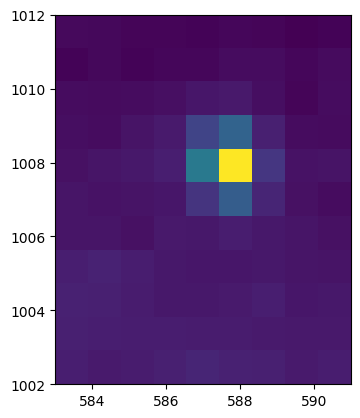

In [137]:
plt.imshow(cube[0,:,:].data[0], origin='lower', extent=[cube.pixel_col[0], cube.pixel_col[-1], cube.pixel_row[0], cube.pixel_row[-1]]) 


<Axes: title={'center': 'Target ID: None, Cadence: 0'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

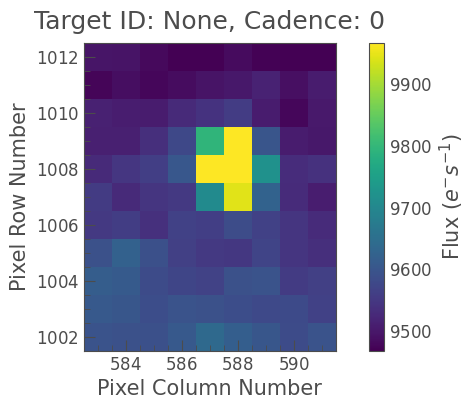

In [138]:
# TODO: I'll probably remove this, but it's a nice sanity check
import lightkurve as lk
tpf = lk.read(manifest['Local Path'][0])
tpf.plot()

In [139]:
# Get the data for the brightest pixel at location (row 6, column 5) for every time step
# Note this now becomes a DataSeries, which is equivalent to a 1-dimensional lightcurve
cube[:,6,5] 

time_index  time          timecorr 
0           2.459526e+06  -0.003259    10405.174805
1           2.459526e+06  -0.003258    10582.315430
2           2.459526e+06  -0.003257    10765.145508
3           2.459526e+06  -0.003257    10921.556641
4           2.459526e+06  -0.003256    11029.963867
                                           ...     
3445        2.459551e+06  -0.000952     1877.079590
3446        2.459551e+06  -0.000951     1875.521240
3447        2.459551e+06  -0.000950     1877.299072
3448        2.459551e+06  -0.000950     1872.148804
3449        2.459551e+06  -0.000949     1873.886963
Length: 3450, dtype: float32


📉 DataSeries (3450,)

In [140]:
# Get the first 10 time steps for the pixels containing the target star
cube[0:10, 4:9, 3:8] # Remember, this is [time, row, column]

📘 DataCube (10, 5, 5), Uncertainty: True

## binning

Often you may want to bin the data. For example, you may want to bin in the time dimension to reduce the noise to bring out features in the data or bin in the spatial dimension to visualize what your data at a lower resolution. The DataCube object makes this easy. 

In [141]:
# Bin together every 5 time steps. By default, this provides sum of the 5 images for each pixel 
# TODO: did Dan get the median/mean, etc options working for this?

# TODO: note this is not a length of 690 (3450/5), so this must mean 3 bins were not 'full' 
cube.downsample(nframes=5, level="time")

📘 DataCube (687, 11, 9), Uncertainty: True

## Other Properties

DataCube objects have other properties you can access directly. These include col, row, and uncertainty. Note col and row are the same for all images in the stack. However, the uncertainties match the dimensions of the data. 

In [142]:
cube.pixel_col.shape, cube.pixel_row.shape, cube.uncertainty.shape


((99,), (99,), (3450, 11, 9))

You can also perform math operations on the DataCube. For example, we could create a 2D image containing the median data for each pixel. Note this returns the median data as well as the associated uncertainties

In [143]:
cube.mean(axis=0) 

(array([[ 441.7092 ,  441.90225,  442.74725,  443.3073 ,  448.73166,
          447.50076,  445.8543 ,  446.03046,  445.97845],
        [ 442.98264,  445.3411 ,  445.21796,  443.34595,  444.92865,
          446.72693,  445.51782,  444.95996,  447.28983],
        [ 449.1061 ,  474.56668,  469.81662,  445.87985,  444.63474,
          446.6372 ,  445.31216,  445.6053 ,  446.59845],
        [ 453.32626,  511.95407,  485.99942,  448.07504,  445.7115 ,
          447.0069 ,  445.11334,  444.72174,  444.5894 ],
        [ 456.06757,  462.3282 ,  454.4368 ,  450.8118 ,  461.6276 ,
          474.29486,  458.18344,  445.43454,  443.7546 ],
        [ 452.08572,  448.93573,  451.87274,  470.7218 ,  612.4403 ,
          826.31006,  555.6611 ,  452.33835,  443.7974 ],
        [ 445.97244,  447.44986,  456.58432,  503.09467,  968.47644,
         2011.2655 ,  652.3894 ,  455.3011 ,  444.74472],
        [ 444.03137,  445.64905,  456.36105,  495.69156,  714.15045,
          924.2393 ,  541.06995,  451.7701

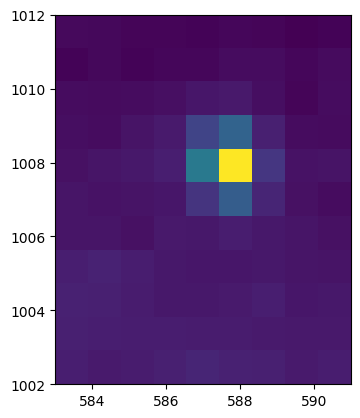

In [144]:
plt.imshow(cube[0,:,:].mean(axis=0)[0], origin='lower', extent=[cube.pixel_col[0], cube.pixel_col[-1], cube.pixel_row[0], cube.pixel_row[-1]]) 

plt.show()


In [145]:
# by default, axis=None, which gives the mean of all data in all dimensions
cube.mean(axis=None)

(490.68353, Uncertainty(0.00184842))

In [146]:
# TODO: can't do cube.uncertainty.mean(). Is this fine? Yes, leave uncertainty math alone
cube.uncertainty.array.mean()

0.96991456

### 3.1 BitwiseCube

As mentioned in the introduction, BitwiseCube was developed to handle the [TESS](https://outerspace.stsci.edu/display/TESS/2.0+-+Data+Product+Overview) and [Kepler/K2](https://archive.stsci.edu/files/live/sites/mast/files/home/missions-and-data/k2/_documents/MAST_Kepler_Archive_Manual_2020.pdf) quality masks. The quality flags are stored in a bitwise operation so that we can easily disentangle all flags attributed to a given time step. When 'adding' bitwise flags, for example when downsampling, we want BitwiseCubes to keep track of all flags that are triggered over the time step. Let's see how this looks in practice below. 

In [147]:
quality_flags = lcf[1].data['QUALITY']
print(quality_flags)
print(np.unique(quality_flags))

[128 128 128 ...   0   0   0]
[    0    32   128   164 16384 16416 16512]


We can see above that a number of quality flags can be found in this TPF. These include
- 0: No quality flag
- 32: Reaction Wheel desaturation Event
- 128: Manual Exclude. The cadence was excluded because of an anomaly
- 164: (128+32+4) Manual Exclude. The cadence was excluded because of an anomaly + Reaction Wheel desaturation Event + Spacecraft is in Coarse Point
- 16384: Bad Calibration Exclude (pipeline >= spoc-4.0.14)
- 16416: (16384 + 32) Bad Calibration Exclude + Reaction Wheel desaturation Event
- 16512: (16384 + 128) Bad Calibration Exclude + Manual Exclude due to an anomaly.

In [148]:
bitwise = lkdata.BitwiseSeries(data=quality_flags,
                       time_indices={'time':time + 2457000},
                          )
bitwise

📗 BitwiseSeries (3450,)

In [149]:
ds = lkdata.DataSeries(data=np.random.random(len(time)),
                       time_indices={'time':time + 2457000},
                          )
ds.downsample(nframes=5, level='time_index')
ds.downsample?

Signature: ds.downsample(nframes: int = 5, level: Union[int, str] = -1)
Docstring:
Downsample the data by averaging over `nframes` consecutive rows.

Parameters
----------
nframes : int, optional
    Number of frames to average over. Default is 5.
level : Union[int, str], optional
    Index level to use for downsampling. Default is -1 (last level).

Returns
-------
Same type as self
    A new object with downsampled data.

Notes
-----
This method works by creating bins of `nframes` consecutive rows,
then averaging the data within each bin. Only bins with exactly
`nframes` rows are included in the result.

If the object has an uncertainty attribute, it will be propagated
by summing the squares of the uncertainties within each bin and
then taking the square root.

The resulting object will have a new index that represents the
mean of the original indices within each bin. If the original
index included a 'time_index' or 'indices' level, this information
is preserved in the new index.
File

In [150]:
# If we 'sum' the bitwise set, we get a list of all individual flags that are found in the BitwiseSet
bitwise.sum()

BitSet {4, 32, 128, 16384}

In [151]:
# downsampling a BitwiseSeries gives the sum of all individual flags found in each bin. 
# TODO: Why is the first time bin missing?
bitwise.downsample(level='time',nframes=5)

📗 BitwiseSeries (687,)

# 4 - Putting it all together with DataSet

Now that we understand the different classes in lkdata, let's try to put it all together. For example, a DataSeries can only contain one data array, but what if we want to tie multiple bits of data together? For example, we may want to track the Simple Aperture Photometry (SAP) as well as the Pre-search Data Conditioning-SAP (PDCSAP) so that if we manipulate the data (by downsampling or slicing) the operation is performed on both DataSets with one command. DataSets allow us to do this. They are also flexible enough to handle any of the different types of data products (DataSeries/Frame/Cube, BoolSeries/Frame/Cube, BitwiseSeries/Frame/Cube). Let's use our K2-18 data from Section 3 as an example. 

In [153]:
# TODO: DataSet docstring is not clear with how DataSet init works. 
# TODO: how do aperture get handled? 
lkdata.DataSet({'tpf':cube, 'quality':bitwise})



Data Products:
{'tpf': 📘 DataCube (3450, 11, 9), Uncertainty: True, 'quality': 📗 BitwiseSeries (3450,)}
Bool Products:
{}
Bitwise Products:
{}
Properties:
[]

In [154]:

lkdata.DataSet({'tpf':cube}, {'quality':bitwise})


Data Products:
{'tpf': 📘 DataCube (3450, 11, 9), Uncertainty: True}
Bool Products:
{'quality': 📗 BitwiseSeries (3450,)}
Bitwise Products:
{}
Properties:
[]

In [155]:
lkdata.DataSet(data_products={'tpf':cube}, bitwise_products={'quality':bitwise})


Data Products:
{'tpf': 📘 DataCube (3450, 11, 9), Uncertainty: True}
Bool Products:
{}
Bitwise Products:
{'quality': 📗 BitwiseSeries (3450,)}
Properties:
[]

In [156]:
dset = lkdata.DataSet(data_products={'tpf':cube}, 
               bool_products={'quality_flag':bitwise.values >0},
               bitwise_products={'quality':bitwise},
               target='K2-18')
dset


Data Products:
{'tpf': 📘 DataCube (3450, 11, 9), Uncertainty: True}
Bool Products:
{'quality_flag': ⚫️⚪️ BoolSeries (3450,)}
Bitwise Products:
{'quality': 📗 BitwiseSeries (3450,)}
Properties:
['target']

In [159]:
# TODO: I expect there to be a describe_cube function like there is for the other products
dset.describe_set()

AttributeError: 'DataSet' object has no attribute 'describe_set'

In [160]:
dset.target

'K2-18'

In [161]:
dset.downsample(2)


Data Products:
{'tpf': 📘 DataCube (1722, 11, 9), Uncertainty: False}
Bool Products:
{'quality_flag': ⚫️⚪️ BoolSeries (1722,)}
Bitwise Products:
{'quality': 📗 BitwiseSeries (1722,)}
Properties:
['target']

In [167]:
# TODO: I expect cubes to be able to handle a spatial downsample
#       I see it in lkdata.dataset.py so why doesn't it work?

dset.spatial_downsample()


AttributeError: 'DataSet' object has no attribute 'spatial_downsample'